# Model Improvement

In [28]:
import sys, os
import pandas as pd
import matplotlib as plt
sys.path.append(os.path.abspath("../src"))

from data_loading import load_data
from preprocessing import preprocess_pipeline
from train import train_model, save_model
from evaluate import evaluate_model, plot_confusion_matrix
from explain import explain_model
from model import get_model
from threshold import find_best_threshold

# Load Data

In [29]:
df = load_data()

Data loaded: (590540, 434)


# Preprocess pipeline

In [30]:
df = preprocess_pipeline(df)
df.head()

Dropping 12 high-missing columns
Encoded 29 categorical columns
Starting feature engineering...
Feature engineering completed
Preprocessing completed


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_38,DeviceType,DeviceInfo,hour,day,time_since_last_txn,txn_count_5,amt_mean,amt_std,amt_max
243924,3230924,0,5787419,23.443,0,1000,555.0,185.0,2,224.0,...,0,2,282,9.478889,2.394954,NaN,0,23.443000,NaN,23.443
36634,3023634,0,916268,183.000,4,1001,555.0,150.0,4,226.0,...,2,1,1735,23.898333,6.995764,NaN,0,79.666667,89.494879,183.000
164336,3151336,0,3504180,29.000,4,1001,555.0,150.0,4,226.0,...,2,1,1735,11.371111,1.473796,127702.0,1,79.666667,89.494879,183.000
223739,3210739,0,5270458,27.000,4,1001,555.0,150.0,4,226.0,...,2,1,1735,3.871944,2.161331,59403.0,2,79.666667,89.494879,183.000
33767,3020767,0,842821,150.000,2,1004,583.0,150.0,4,226.0,...,0,0,723,23.101944,6.962581,NaN,0,136.400000,93.577775,226.000


# Train Improved Model

In [31]:
model, X_val, y_val = train_model(df)

Scale_pos_weight: 27.579586700866283
[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.120685 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 39694
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 426
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101


# Evaluate baseline vs improved

In [32]:
roc_auc, pr_auc = evaluate_model(model, X_val, y_val)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.9699132682356396
PR-AUC: 0.8176972449659488
Best threshold: 0.8000000000000003, Best F1: 0.7705802968960864

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    113975
           1       0.87      0.69      0.77      4133

    accuracy                           0.99    118108
   macro avg       0.93      0.84      0.88    118108
weighted avg       0.98      0.99      0.98    118108

ROC-AUC: 0.9699132682356396
PR-AUC: 0.8176972449659488


# Threshold tuning analysis

In [33]:
probs = model.predict_proba(X_val)[:, 1]

best_threshold = find_best_threshold(y_val, probs)
print("Best threshold:", best_threshold)

Best threshold: 0.8000000000000003, Best F1: 0.7705802968960864
Best threshold: 0.8000000000000003


# Compare performance

In [34]:
results = pd.DataFrame({
    "Metric": ["ROC-AUC", "PR-AUC"],
    "Value": [roc_auc, pr_auc]
})

results

,Metric,Value
0,ROC-AUC,0.969913
1,PR-AUC,0.817697


# Confusion matrix

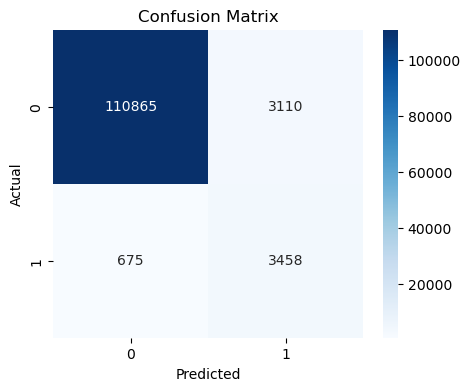

array([[110865,   3110],
       [   675,   3458]])

In [35]:
plot_confusion_matrix(model, X_val, y_val)

# SHAP explainability

Generating SHAP explanation...


/opt/anaconda3/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


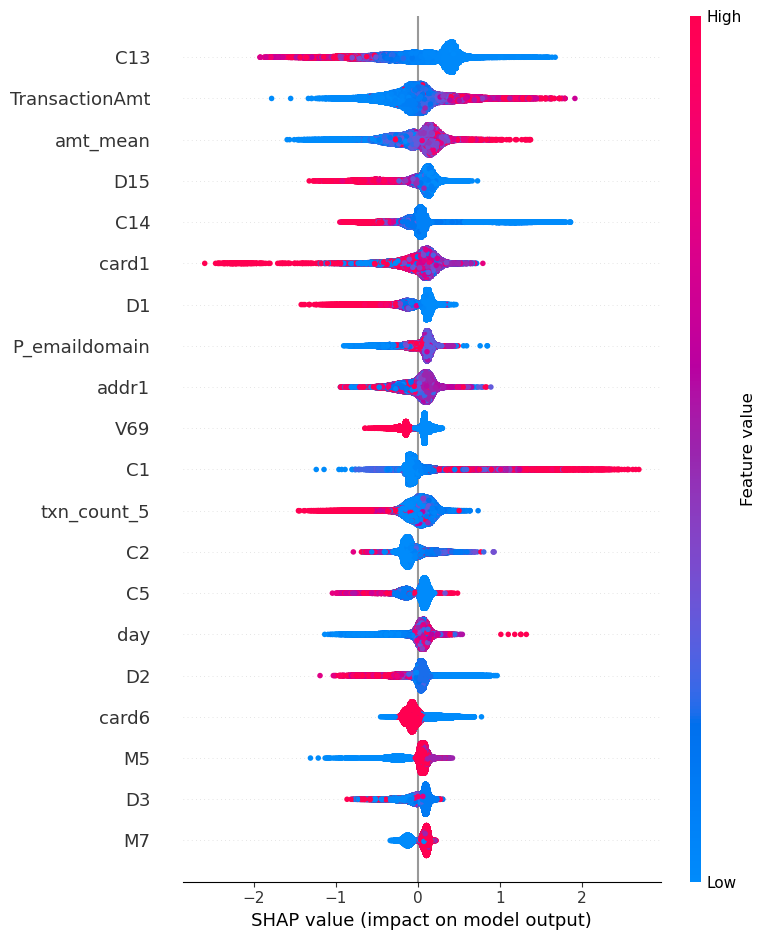

In [24]:
explain_model(model, X_val)

# Save Improved Model

In [37]:
save_model(model, "fraud_detection.pkl")

Model saved at: ../models/fraud_detection.pkl
